## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading dataset

In [2]:
df = pd.read_csv('employees_messy.csv')
df.head()

,emp_id,age,gender,department,city,education,experience,salary,satisfaction,attrition
0,1,37.0,female,Finance,Lahore,Bachelor,9.5,79692.0,1.0,No
1,2,27.0,M,Finance,Peshawar,Master,9.7,74476.0,3.0,No
2,3,41.0,Male,Finance,Karachi,Bachelor,9.6,77414.0,3.0,No
3,4,43.0,Male,HR,Peshawar,Master,7.3,79300.0,4.0,No
4,5,19.0,Male,Marketing,Multan,Bachelor,11.3,85639.0,5.0,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   emp_id        203 non-null    int64  
 1   age           189 non-null    float64
 2   gender        203 non-null    str    
 3   department    203 non-null    str    
 4   city          203 non-null    str    
 5   education     203 non-null    str    
 6   experience    203 non-null    float64
 7   salary        178 non-null    float64
 8   satisfaction  193 non-null    float64
 9   attrition     203 non-null    str    
dtypes: float64(4), int64(1), str(5)
memory usage: 16.0 KB


In [4]:
df.describe

<bound method NDFrame.describe of      emp_id   age  gender department       city    education  experience  \
0         1  37.0  female    Finance     Lahore     Bachelor         9.5   
1         2  27.0       M    Finance   Peshawar       Master         9.7   
2         3  41.0    Male    Finance    Karachi     Bachelor         9.6   
3         4  43.0    Male         HR   Peshawar       Master         7.3   
4         5  19.0    Male  Marketing     Multan     Bachelor        11.3   
..      ...   ...     ...        ...        ...          ...         ...   
198     199  35.0    Male         HR   Peshawar  High School         0.4   
199     200  34.0       F      Sales  Islamabad       Master         0.2   
200       1  37.0  female    Finance     Lahore     Bachelor         9.5   
201       2  27.0       M    Finance   Peshawar       Master         9.7   
202       3  41.0    Male    Finance    Karachi     Bachelor         9.6   

      salary  satisfaction attrition  
0    79692.0  

In [5]:
df.shape

(203, 10)

In [6]:
df.describe()

,emp_id,age,experience,salary,satisfaction
count,203.000000,189.000000,203.000000,178.000000,193.000000
mean,99.044335,35.248677,7.924631,90034.146067,2.880829
std,58.670442,10.891465,3.896290,89719.688065,1.399887
min,1.000000,18.000000,0.000000,-11210.000000,1.000000
25%,48.500000,30.000000,5.100000,68071.250000,2.000000
50%,99.000000,35.000000,8.100000,81134.500000,3.000000
75%,149.500000,39.000000,10.550000,95249.750000,4.000000
max,200.000000,150.000000,20.700000,950000.000000,5.000000


# age cannot be 150
# max salary is too high
# non null count is below 203 for Salary, age, satisfaction. (missing values)

In [20]:
# count and percentage of missing values

missing = df.isnull().sum()
missing_percent = ((missing/len(df))*100).round(1)

# print missing and its percentage

pd.DataFrame({"missing": missing, "Percentage": missing_percent}).query("missing > 0").sort_values("missing", ascending=False) 

,missing,Percentage
salary,25,12.3
age,14,6.9
satisfaction,10,4.9


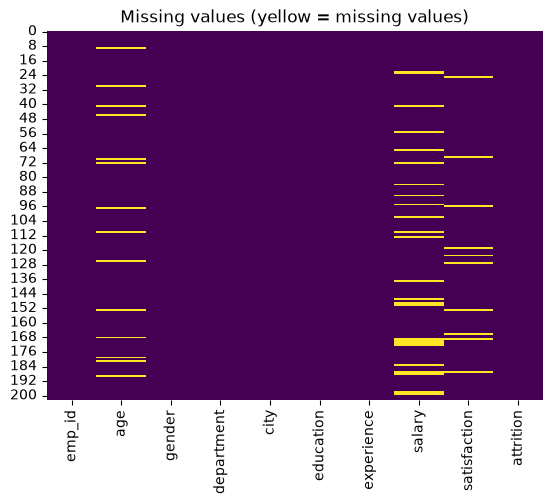

In [25]:
# Mapping the missing values

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values (yellow = missing values)")
plt.show()

## Filling the missing values (imputation)

- **Median** is safer than mean for `salary` because salary has outliers
  (the mean gets dragged up; the median doesn't).
- **Mode** (most frequent value) for the categorical/rating `satisfaction`.

In [26]:
df_clean = df.copy()

#fill age with median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

#fill satisfaction with mode
df_clean["satisfaction"] = df_clean["satisfaction"].fillna(df_clean["satisfaction"].mode()[0])

## Groupwise imputation

In [28]:
#median salary per department)
print(df_clean.groupby("department")["salary"].median().round(0))

department
Engineering    77257.0
Finance        79692.0
HR             88276.0
Marketing      83149.0
Sales          76036.0
Name: salary, dtype: float64


In [32]:
#fill each missing salary by its median 
df_clean["salary"] = df_clean.groupby("department")["salary"].transform(lambda s: s.fillna(s.median()))

#check if any missing values
print("\nRemaining missing values: ", df_clean.isnull().sum().sum())


Remaining missing values:  0


## Remove Duplicates

In [35]:
#find if any duplicates
print("Duplicates found: ",df_clean.duplicated().sum())

Duplicates found:  3


In [37]:
#delete the duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("shape after removing the duplicates:",df_clean.shape)

shape after removing the duplicates: (200, 10)


## Cleaning categorical data

In [38]:
#Find the categories
print("Gender before cleaning:", df_clean["gender"].value_counts())

Gender before cleaning: gender
M         40
female    38
F         34
Female    33
Male      32
male      23
Name: count, dtype: int64


In [39]:
#standardize gender to M, F
gender_map ={"m":"M", "male":"M","f":"F", "female":"F"}

df_clean["gender"] = df_clean["gender"].str.strip().str.lower().map(gender_map)

print("Gender AFTER cleaning:")
print(df_clean["gender"].value_counts())

Gender AFTER cleaning:
gender
F    105
M     95
Name: count, dtype: int64


## Detecting outliers using boxplot

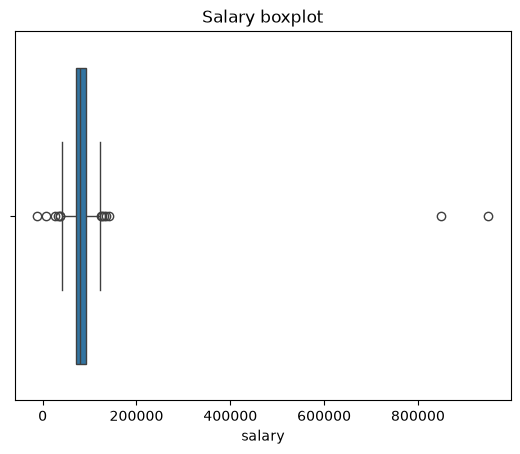

In [40]:
sns.boxplot(x=df_clean["salary"])
plt.title("Salary boxplot")
plt.show()

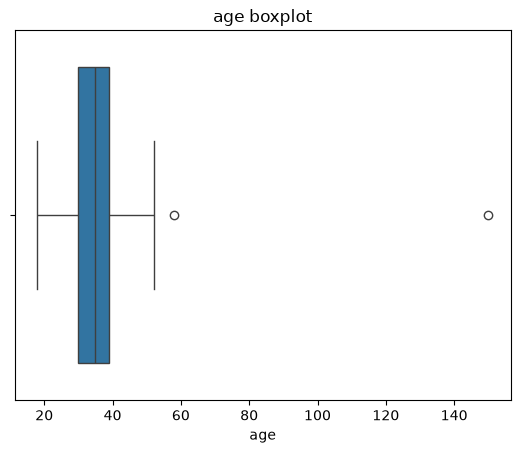

In [41]:
sns.boxplot(x=df_clean["age"])
plt.title("age boxplot")
plt.show()

## detecting outliers using IQR (Interquartile Range) rule

- Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 − Q1
- Anything **below Q1 − 1.5·IQR** or **above Q3 + 1.5·IQR** is an outlier.
- Works on any distribution (doesn't assume a bell curve) — the default choice.


In [42]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr,  q3 + 1.5*iqr

low, high = iqr_bounds(df_clean["salary"])

print(f"Salary outlier bounds: {low:,.0f} to {high:,.0f}")
print("Salary outliers:", ((df_clean["salary"] < low) | (df_clean["salary"] > high)).sum())

Salary outlier bounds: 38,539 to 123,552
Salary outliers: 13


In [43]:
#Look at the flagged rows before deciding anything!
df_clean[(df_clean["salary"] < low) | (df_clean["salary"] > high)][
    ["emp_id", "department", "experience", "salary"]]

,emp_id,department,experience,salary
5,6,Engineering,10.5,950000.0
12,13,HR,6.2,850000.0
13,14,HR,6.3,37400.0
29,30,Engineering,4.1,131507.0
43,44,Marketing,3.9,32980.0
49,50,Marketing,13.8,127054.0
71,72,Finance,10.1,6735.0
73,74,Sales,4.4,-11210.0
74,75,Finance,8.0,36913.0
81,82,Marketing,11.4,136073.0


## Detecting outliers using Z score
The Z-score measures **how many standard deviations** a value is from the mean:

$$ z = \frac{x - \text{mean}}{\text{std}} $$

A common threshold: **|z| > 3** → outlier. Best when the data is roughly
bell-shaped (normal). Caveat: the outliers themselves inflate the mean and std
used in the formula, so extreme outliers can "hide" smaller ones — which is why
IQR (based on percentiles, not the mean) is often more robust.

In [45]:
z = (df_clean["salary"] - df_clean["salary"].mean() )/ df_clean["salary"].std()

print("salary values for |z| > 3:\n ", df_clean.loc[z.abs() > 3, "salary"].to_string())

salary values for |z| > 3:
  5     950000.0
12    850000.0


# only two are flagged in comparison to IQR
# Treating outliers

In [46]:
#cap salary to IQR bounds
df_clean["salary"] = df_clean["salary"].clip(lower=low, upper=high)

#age=150 not possible
df_clean["age"] = df_clean["age"].clip(lower=18, upper=65)

print("Salary max after capping:", df_clean["salary"].max())
print("Age max after capping:   ", df_clean["age"].max())

Salary max after capping: 123552.375
Age max after capping:    65.0


## log transform of skewed data

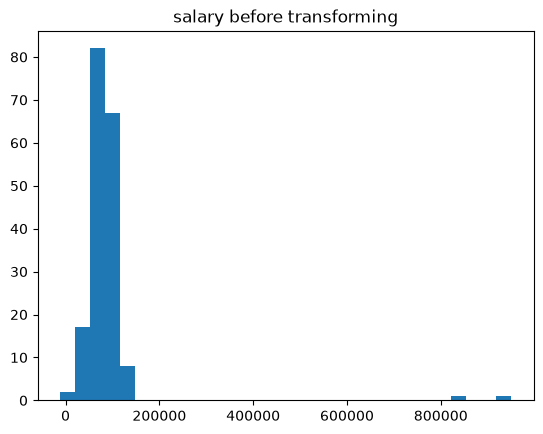

In [ ]:
#before transformation
plt.hist(df["salary"], bins=30)
plt.title("salary before transforming")
plt.show()

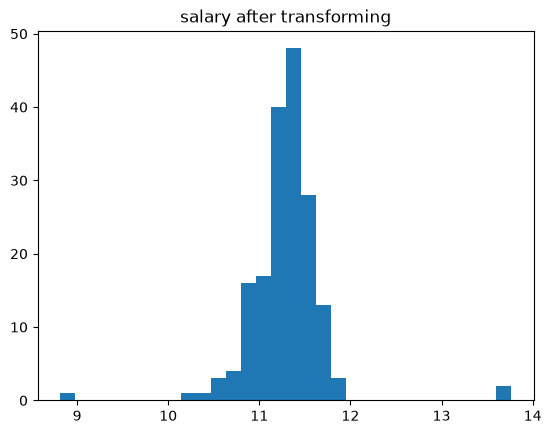

In [53]:
#after transformation
plt.hist(np.log1p(df["salary"].dropna()), bins=30)
plt.title("salary after transforming")
plt.show()

## Encoding categorical variables
Models need **numbers**, not text. But *how* you convert matters — the wrong
encoding feeds the model false information.

### Step 1: classify each categorical column

| Type | Definition | Our examples | Right encoding |
|---|---|---|---|
| **Binary** | exactly 2 values | `gender`, `attrition` | map to 0/1 |
| **Ordinal** | categories with a natural ORDER | `education` (HS < Bachelor < Master < PhD) | ordinal encoding — integers that respect the order |
| **Nominal** | categories with NO order | `department`, `city` | one-hot encoding |

**Why not just number everything 0, 1, 2, 3?** If we encode
`Sales=0, HR=1, Finance=2`, the model reads that as *"Finance is twice HR"*
and *"Sales < HR < Finance"* — relationships that **don't exist**. That's why
nominal data gets one-hot encoding instead.

## binary/ordinal variables

In [ ]:
df_clean.info()

#binary attrition,gender to 0,1
df_clean["attrition"] = df_clean["attrition"].map({"yes": 1, "no": 0})
df_clean["gender"] = df_clean["gender"].map({"M": 0, "F": 1})

#ordinal education
edu_order={"High school": 1, "Bachelor": 2, "Master": 3, "Phd": 4}
df_clean["education"] = df_clean["education"].map(edu_order)

df_clean[["attrition","gender","education"]].head()